#Goals of this book:

- Prepare data
    -load processed data from (data/processed)
    -ensure labeled columns are present
    -split data into trainingg and test sets
-Train Models
-Track the model run and experiments with MFLOW
    Log parameters, metrics and artifacts
-Evaluate
    - use classification metrics (precsion/recall/confusion matrix, AUC)
    - Export feature importance

In [33]:
import os
import json
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

random_state = 42

ROOT = Path.cwd().resolve()
DATA_DIR = Path(r"C:\Users\payou\ClaimsAI\data\processed")
DEFAULT_FILE = DATA_DIR / "beneficiary_labeled.csv"

import mlflow
import mlflow.sklearn

pd.set_option("display.max_columns", 120)
pd.set_option("display.width",180)

In [34]:
#Load Dataset

if not DEFAULT_FILE.exists():
    raise FileNotFoundError(f"Expected file not found: {DEFAULT_FILE}\n"
                            f"Place a processed, labeled file in {DATA_DIR} or update DEFAULT_FILE.")

df = pd.read_csv(DEFAULT_FILE) if DEFAULT_FILE.suffix == ".csv" else pd.read_csv(DEFAULT_FILE)

print(f"Loaded shape: {df.shape}")
display(df.head(3))

Loaded shape: (349064, 18)


,AGE,Date_of_Death,Gender,Race,total_coverage_months,chronic_count,avg_reimb,op_ratio,car_ratio,Number_of_months_covered_a,Numver_of_months_covered_b,Number_of_months_HMO_coverage,Number_of_months_covered_d,is_anomaly,y_rule,rule_R_high_cost,rule_R_high_out_ratio,rule_R_high_chronic
0,51,0,Female,Hispanic,24,13,3551.200000,0.018765,0.075859,12,12,0,0,1,1,1,0,0
1,51,0,Female,White,36,15,509.459459,0.132720,0.254976,12,12,0,12,1,1,1,0,0
2,51,0,Male,White,48,13,798.775510,0.002667,0.040956,12,12,12,12,1,1,1,0,0


In [35]:
#Choose Target feature 

# Candidate target names from your labeling notebook(s).
# Adjust this list to match what you created (binary labels preferred for baseline).
CANDIDATE_TARGETS = [
    "anomaly_flag",      # 0/1
    "fraud_label",       # 0/1
    "is_anomaly"         # 0/1
]

target_col = next((c for c in CANDIDATE_TARGETS if c in df.columns), None)

if target_col:
    print(f"Using supervised target: {target_col}")
else:
    print("No supervised label found — we'll run unsupervised (IsolationForest) in the modeling chunk.")

# Exclude obvious non-features: identifiers, date keys, and the target itself.
ID_LIKE = [
    "DESYNPUF_ID", "BENE_ID", "CLM_ID", "NPI", "HICNO"
]
DATE_LIKE = [c for c in df.columns if "DT" in c or "DATE" in c or c.endswith("_DT") or c.endswith("_DATE")]

drop_cols = set(ID_LIKE + DATE_LIKE + ([target_col] if target_col else []))
feature_cols = [c for c in df.columns if c not in drop_cols]

print(f"Feature count: {len(feature_cols)}")

Using supervised target: is_anomaly
Feature count: 17


In [36]:
#Target Set up

target_col = "is_anomaly"

#feature column set up (all columns minus IDs, target and Dates)
id_like = ["DESYNPUF_ID", "BENE_ID", "CLM_ID", "NPI", "HICNO"]
date_like = [c for c in df.columns if "DT" in c or "Date" in c or c.endswith("_DT") or c.endswith("_DATE") or c.startswith("Date_")]

#Data Leakage columns
leaky_cols = ['y_rule', 'rule_R_high_cost', 'rule_R_high_out_ratio', 'rule_R_high_chronic','avg_reimb', 'op_ratio', 'car_ratio',]

drop_cols = set(id_like + date_like + [target_col])
feature_cols = ['AGE', 'Gender', 'Race', 'total_coverage_months',
    'chronic_count', 'Number_of_months_covered_a', 'Numver_of_months_covered_b',
    'Number_of_months_HMO_coverage', 'Number_of_months_covered_d']

print(f"Target column: {target_col}")
print(f"Feature count: {len(feature_cols)}")

Target column: is_anomaly
Feature count: 9


In [37]:
print(feature_cols)

['AGE', 'Gender', 'Race', 'total_coverage_months', 'chronic_count', 'Number_of_months_covered_a', 'Numver_of_months_covered_b', 'Number_of_months_HMO_coverage', 'Number_of_months_covered_d']


In [38]:
#Split Data into training and test

from sklearn.model_selection import train_test_split

X = df[feature_cols].copy()
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

print("\nClass balance in training set:")
print(y_train.value_counts(normalize=True).rename("proportion").round(3))


Training samples: 279251
Testing samples: 69813

Class balance in training set:
is_anomaly
1    0.737
0    0.263
Name: proportion, dtype: float64


In [39]:
#Feature encoding, pipeline creation and transformation

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identify column types
numeric_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
categorical_cols = [c for c in X_train.columns if not pd.api.types.is_numeric_dtype(X_train[c])]

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Define the transformations
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine them
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)


Numeric columns: 7
Categorical columns: 2


In [40]:
#Modeling Training - XGBOOST

from xgboost import XGBClassifier

# Compute imbalance ratio for weighting
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Class imbalance ratio (neg/pos): {ratio:.2f}")

# Define model
xgb_model = XGBClassifier(
    n_estimators=300,          # number of boosting rounds
    learning_rate=0.05,        # smaller = slower but better generalization
    max_depth=5,               # tree depth (controls complexity)
    subsample=0.8,             # row sampling for regularization
    colsample_bytree=0.8,      # feature sampling for regularization
    scale_pos_weight=ratio,    # helps with imbalance
    eval_metric="aucpr",       # AUC of precision-recall curve
    random_state=42,
    n_jobs=-1
)

# Build full pipeline (preprocessing + model)
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

# Train
model_pipeline.fit(X_train, y_train)

print("✅ Model training complete.")


Class imbalance ratio (neg/pos): 0.36
✅ Model training complete.


ROC-AUC: 0.945
PR-AUC: 0.979

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0      0.668     0.991     0.798     18341
           1      0.996     0.825     0.902     51472

    accuracy                          0.868     69813
   macro avg      0.832     0.908     0.850     69813
weighted avg      0.910     0.868     0.875     69813



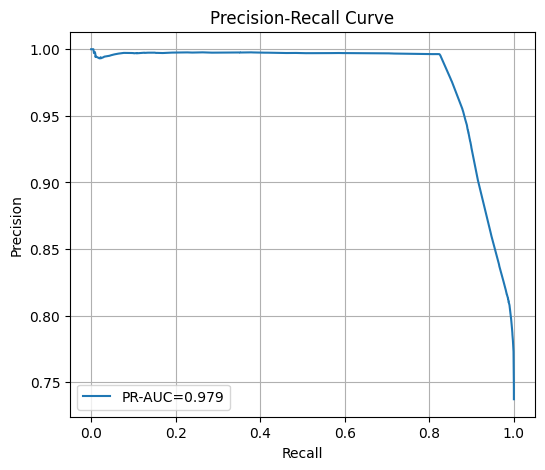

In [41]:
#Model Evaluation

from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_prob = model_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)

# Compute metrics
roc_auc = roc_auc_score(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")
print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred, digits=3))

# Plot PR curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR-AUC={pr_auc:.3f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
#Exploring why results happened

# Find any features perfectly correlated with the label
corrs = df[feature_cols + [target_col]].corr(numeric_only=True)[target_col].abs().sort_values(ascending=False)
print(corrs.head(10))


is_anomaly                       1.000000
chronic_count                    0.535737
Numver_of_months_covered_b       0.410717
Number_of_months_covered_a       0.250583
total_coverage_months            0.216872
Number_of_months_covered_d       0.068371
Number_of_months_HMO_coverage    0.016057
AGE                                   NaN
Name: is_anomaly, dtype: float64
